# Mini Project 1: Exploratory Data Analysis (EDA)

## Dataset Overview
This dataset contains customer analytics information including demographic details, income, and spending behavior.

Each row represents one unique customer record.

The goal of this analysis is to:
- Understand the structure of the dataset
- Clean and preprocess the data
- Discover patterns in customer behavior
- Generate meaningful insights


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('customer_analytics.csv')
print('Shape of dataset:', df.shape)
df.head()

Shape of dataset: (255, 14)


,CustomerID,Age,Gender,City,Education,MaritalStatus,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,PreferredDevice,LastPurchaseAmount
0,1001,49,Male,Pune,Masters,Single,82953.0,66,23,19,9,2,Laptop,3944
1,1002,44,Male,Pune,PhD,Single,60610.0,56,22,1,23,3,Desktop,3885
2,1003,42,Male,Mumbai,Bachelors,Single,35501.0,44,18,10,29,3,Laptop,3247
3,1004,36,Female,Mumbai,Masters,Married,99312.0,36,10,12,21,3,Mobile,2028
4,1005,23,Male,Pune,Masters,Married,46980.0,56,1,18,9,3,Tablet,1100


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CustomerID            255 non-null    int64  
 1   Age                   255 non-null    int64  
 2   Gender                255 non-null    object 
 3   City                  255 non-null    object 
 4   Education             243 non-null    object 
 5   MaritalStatus         255 non-null    object 
 6   AnnualIncome          243 non-null    float64
 7   SpendingScore         255 non-null    int64  
 8   YearsEmployed         255 non-null    int64  
 9   PurchaseFrequency     255 non-null    int64  
 10  OnlineVisitsPerMonth  255 non-null    int64  
 11  ReturnedItems         255 non-null    int64  
 12  PreferredDevice       255 non-null    object 
 13  LastPurchaseAmount    255 non-null    int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 28.0+ KB


In [3]:
df.describe()

,CustomerID,Age,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,LastPurchaseAmount
count,255.000000,255.000000,243.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.00000
mean,1126.941176,37.729412,74499.901235,45.721569,14.682353,11.568627,16.078431,1.858824,2795.07451
std,72.397256,9.767842,43939.855655,17.869522,9.651664,7.077899,7.909536,1.409917,1328.77241
min,1001.000000,21.000000,16062.000000,5.000000,1.000000,1.000000,3.000000,0.000000,566.00000
25%,1064.500000,29.000000,56353.000000,34.500000,6.000000,5.000000,10.000000,1.000000,1542.50000
50%,1128.000000,38.000000,69629.000000,47.000000,15.000000,11.000000,16.000000,2.000000,2705.00000
75%,1190.500000,46.000000,84030.500000,57.500000,23.000000,18.000000,23.000000,3.000000,4001.00000
max,1250.000000,54.000000,474327.000000,95.000000,34.000000,24.000000,29.000000,4.000000,4996.00000


## Phase 2: Data Cleaning


In [4]:
df.isnull().sum()

CustomerID               0
Age                      0
Gender                   0
City                     0
Education               12
MaritalStatus            0
AnnualIncome            12
SpendingScore            0
YearsEmployed            0
PurchaseFrequency        0
OnlineVisitsPerMonth     0
ReturnedItems            0
PreferredDevice          0
LastPurchaseAmount       0
dtype: int64

In [5]:
# Fill missing AnnualIncome with median
if 'AnnualIncome' in df.columns:
    df['AnnualIncome'].fillna(df['AnnualIncome'].median(), inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

print('Duplicates after cleaning:', df.duplicated().sum())

Duplicates after cleaning: 0


C:\Users\Jeevan K\AppData\Local\Temp\ipykernel_20108\2588070621.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['AnnualIncome'].fillna(df['AnnualIncome'].median(), inplace=True)


### Cleaning Justification
- Missing AnnualIncome values were replaced with the median to reduce the effect of outliers.
- Duplicate rows were removed to ensure unique customer records.


## Phase 3: Univariate Analysis


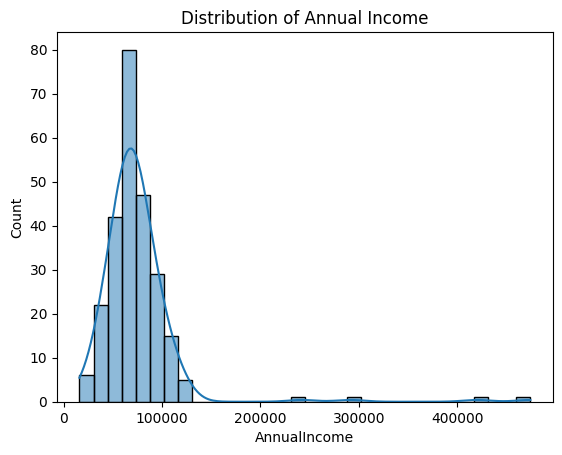

In [6]:
sns.histplot(df['AnnualIncome'], kde=True)
plt.title('Distribution of Annual Income')
plt.show()

Annual income appears slightly right-skewed, indicating some high-income outliers.


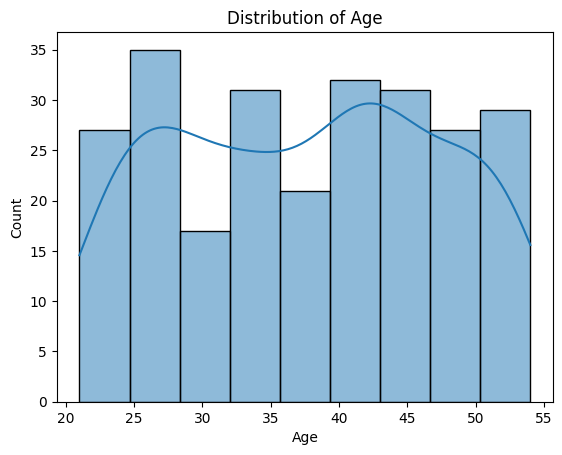

In [7]:
sns.histplot(df['Age'], kde=True)
plt.title('Distribution of Age')
plt.show()

Customer age distribution is relatively balanced across working-age groups.


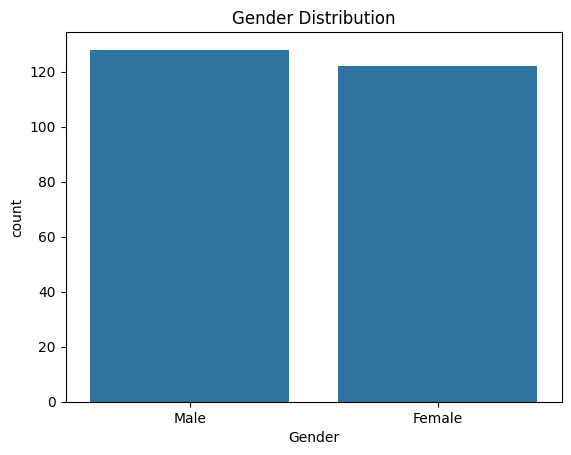

In [8]:
sns.countplot(data=df, x='Gender')
plt.title('Gender Distribution')
plt.show()

Gender distribution appears reasonably balanced.


## Phase 3: Bivariate Analysis


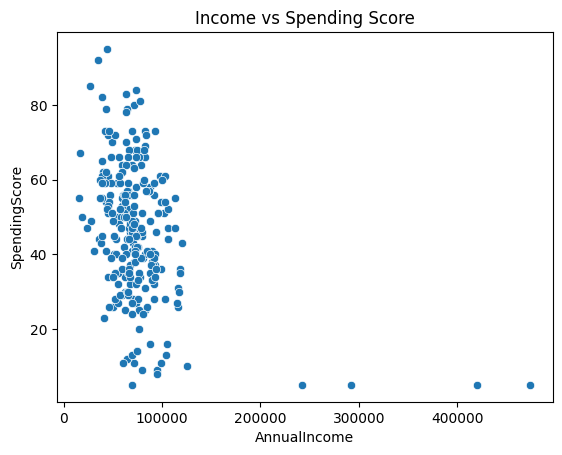

In [9]:
sns.scatterplot(data=df, x='AnnualIncome', y='SpendingScore')
plt.title('Income vs Spending Score')
plt.show()

There is a moderate relationship between income and spending behavior.


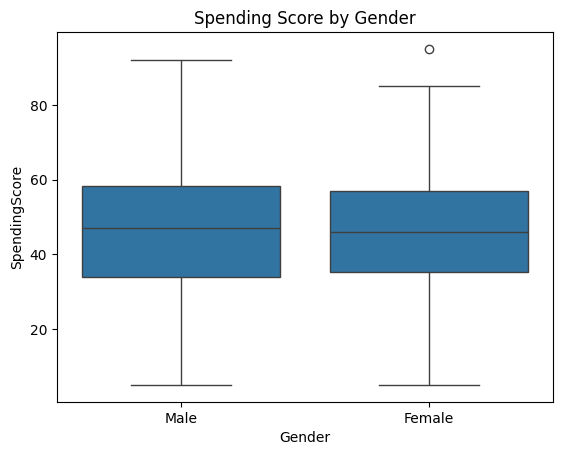

In [10]:
sns.boxplot(data=df, x='Gender', y='SpendingScore')
plt.title('Spending Score by Gender')
plt.show()

Spending patterns appear similar across genders.


## Phase 4: Correlation Analysis


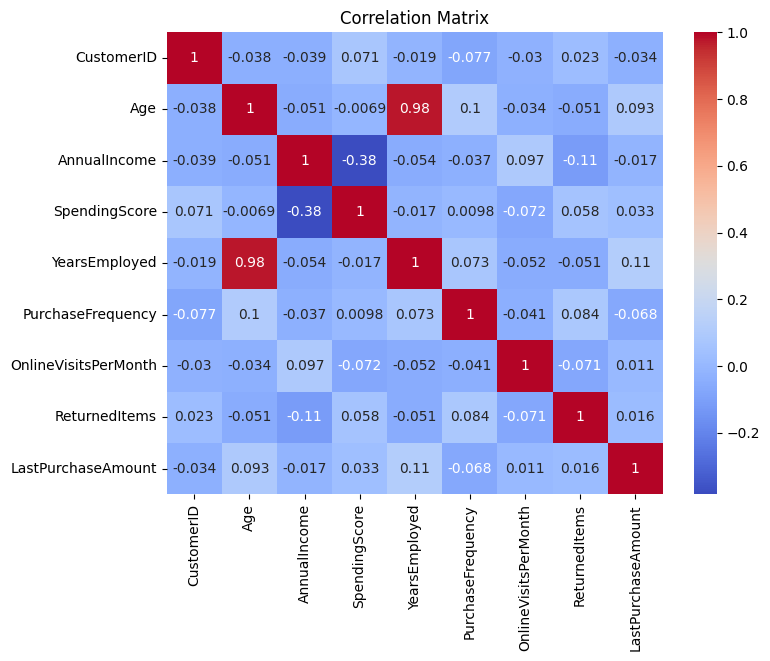

In [11]:
plt.figure(figsize=(8,6))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Executive Summary

1. Income distribution shows presence of high-income outliers.
2. Moderate relationship observed between income and spending behavior.
3. Dataset was successfully cleaned and prepared for further modeling.
